# Lab 7: Decision Tree Classifier - Iris Dataset

**Reg:** 2547106  
**Dataset:** `sklearn.datasets.load_iris()`


## Setup

Import the required libraries and load the Iris data into a labelled DataFrame.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.style.use('seaborn-v0_8-whitegrid')
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')
class_names = iris.target_names
feature_names = iris.feature_names
df = X.copy()
df['species'] = pd.Categorical.from_codes(y, class_names)
print('Dataset loaded successfully.')

Dataset loaded successfully.


## Task 1: Dataset Exploration

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Class distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


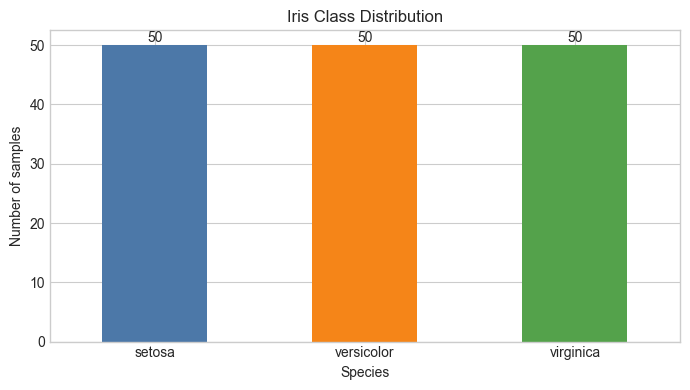

Each species has 50 samples, so the complete Iris dataset is balanced.


In [2]:
print(f'Number of samples: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')
print('Feature names:', list(feature_names))
print('Target classes:', list(class_names))

print('\nFirst five records:')
display(df.head())

class_distribution = df['species'].value_counts().reindex(class_names)
print('Class distribution:')
display(class_distribution.rename('count').to_frame())

ax = class_distribution.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'], rot=0, figsize=(7, 4))
ax.set(title='Iris Class Distribution', xlabel='Species', ylabel='Number of samples')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

print('Each species has 50 samples, so the complete Iris dataset is balanced.')

## Task 2: Data Preparation

The data is split into 80% training and 20% testing data with `random_state=42`. 

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0] / len(X):.0%})')
print(f'Testing set:  {X_test.shape[0]} samples ({X_test.shape[0] / len(X):.0%})')

Training set: 120 samples (80%)
Testing set:  30 samples (20%)


## Task 3: Building and Evaluating a Default Decision Tree

A default `DecisionTreeClassifier` uses the Gini criterion. Evaluation includes the required accuracy score, confusion matrix, and classification report. The confusion-matrix heatmap makes correct and incorrect class predictions easy to inspect.

Test accuracy: 1.000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



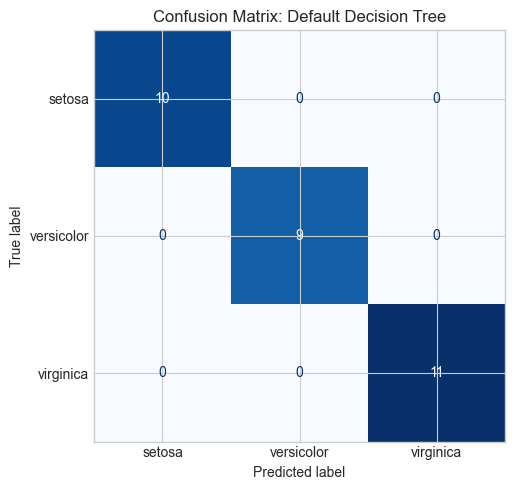

In [4]:
default_tree = DecisionTreeClassifier()
default_tree.fit(X_train, y_train)
y_pred = default_tree.predict(X_test)
default_accuracy = accuracy_score(y_test, y_pred)

print(f'Test accuracy: {default_accuracy:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=class_names, cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Confusion Matrix: Default Decision Tree')
plt.tight_layout()
plt.show()

## Task 4: Visualizing the Decision Tree

The plot below is the required tree visualization. The following cell identifies its root, internal nodes, leaf nodes, maximum depth, and explains the first split using the learned tree object rather than relying on a manual reading of the diagram.

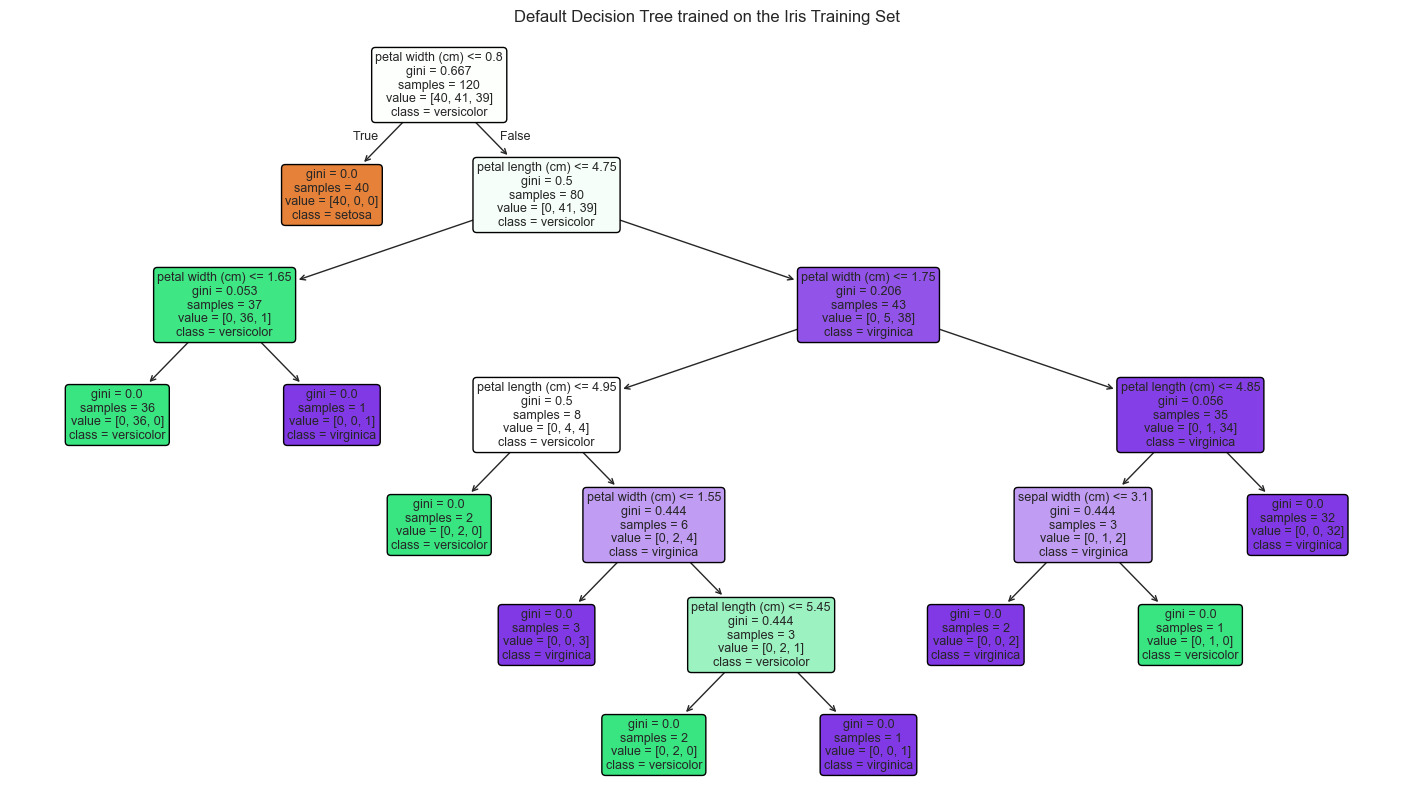

Root node: node 0, split: petal width (cm) <= 0.80
Number of internal nodes: 9
Number of leaf nodes: 10
Maximum tree depth: 6
First split feature: petal width (cm)
Commentary: The root feature was selected because its split produced the largest Gini-impurity reduction among the candidate splits considered at the root.


In [5]:
plt.figure(figsize=(18, 10))
plot_tree(
    default_tree, feature_names=feature_names, class_names=class_names,
    filled=True, rounded=True, impurity=True, fontsize=9
)
plt.title('Default Decision Tree trained on the Iris Training Set')
plt.show()

tree_structure = default_tree.tree_
internal_mask = tree_structure.children_left != tree_structure.children_right
leaf_mask = ~internal_mask
root_feature_index = tree_structure.feature[0]
root_feature = feature_names[root_feature_index]
root_threshold = tree_structure.threshold[0]

print(f'Root node: node 0, split: {root_feature} <= {root_threshold:.2f}')
print(f'Number of internal nodes: {internal_mask.sum()}')
print(f'Number of leaf nodes: {leaf_mask.sum()}')
print(f'Maximum tree depth: {default_tree.get_depth()}')
print(f'First split feature: {root_feature}')
print('Commentary: The root feature was selected because its split produced the largest Gini-impurity reduction among the candidate splits considered at the root.')

## Task 5: Comparing Gini Index and Entropy

Both models are trained on exactly the same split. The table compares test accuracy, tree depth, number of leaves, root feature, and which model is simpler (smaller depth first, then fewer leaves).

In [6]:
criterion_models = {}
comparison_rows = []
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion)
    model.fit(X_train, y_train)
    criterion_models[criterion] = model
    comparison_rows.append({
        'Criterion': criterion.title(),
        'Test Accuracy': accuracy_score(y_test, model.predict(X_test)),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves(),
        'Root Feature': feature_names[model.tree_.feature[0]]
    })

criterion_results = pd.DataFrame(comparison_rows)
complexity = criterion_results[['Tree Depth', 'Leaf Nodes']].apply(tuple, axis=1)
simplest_index = complexity.idxmin()
criterion_results['Simpler Tree?'] = ['Yes' if i == simplest_index else 'No' for i in criterion_results.index]
display(criterion_results.style.format({'Test Accuracy': '{:.3f}'}))
print(f"Based on depth and then leaf count, the simpler model is {criterion_results.loc[simplest_index, 'Criterion']}.")

,Criterion,Test Accuracy,Tree Depth,Leaf Nodes,Root Feature,Simpler Tree?
0,Gini,1.000,6,10,petal length (cm),Yes
1,Entropy,1.000,6,10,petal width (cm),No


Based on depth and then leaf count, the simpler model is Gini.


## Task 6: Effect of Maximum Tree Depth

This experiment changes only `max_depth`. Training and testing accuracy are shown together to reveal underfitting (both low) and possible overfitting (a large gap between training and testing performance).

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.675,0.633,1,Likely underfitting: training accuracy is low.
1,2,0.950,0.967,2,Good balance on this split.
2,3,0.958,1.000,3,Good balance on this split.
3,4,0.975,1.000,4,Good balance on this split.
4,None,1.000,1.000,6,Good balance on this split.


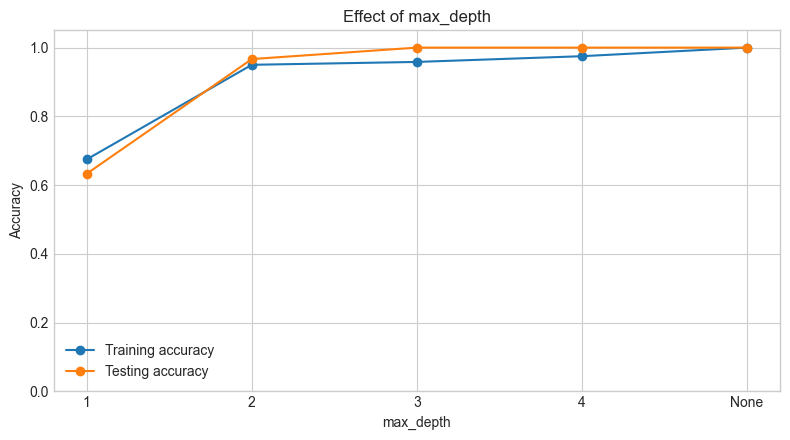

Underfitting model(s): 1.
Best generalization on this test split: max_depth=3 (testing accuracy 1.000).
Overfitting: no tested depth shows a substantial train-test gap on this particular split; an unrestricted tree still has the greatest capacity to overfit on other data.


In [7]:
def depth_observation(train_acc, test_acc):
    gap = train_acc - test_acc
    if train_acc < 0.90:
        return 'Likely underfitting: training accuracy is low.'
    if gap >= 0.08:
        return 'Possible overfitting: noticeable train-test gap.'
    return 'Good balance on this split.'

depth_rows = []
depth_models = {}
for max_depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=max_depth)
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    label = 'None' if max_depth is None else str(max_depth)
    depth_models[label] = model
    depth_rows.append({
        'Max Depth': label, 'Training Accuracy': train_acc, 'Testing Accuracy': test_acc,
        'Tree Depth': model.get_depth(), 'Observation': depth_observation(train_acc, test_acc)
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results.style.format({'Training Accuracy': '{:.3f}', 'Testing Accuracy': '{:.3f}'}))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depth_results['Max Depth'], depth_results['Training Accuracy'], marker='o', label='Training accuracy')
ax.plot(depth_results['Max Depth'], depth_results['Testing Accuracy'], marker='o', label='Testing accuracy')
ax.set(title='Effect of max_depth', xlabel='max_depth', ylabel='Accuracy', ylim=(0, 1.05))
ax.legend()
plt.tight_layout()
plt.show()

best_depth = depth_results.loc[depth_results['Testing Accuracy'].idxmax()]
underfit_depths = depth_results.loc[depth_results['Training Accuracy'] < 0.90, 'Max Depth'].tolist()
overfit_candidates = depth_results.assign(Gap=depth_results['Training Accuracy'] - depth_results['Testing Accuracy'])
overfit_rows = overfit_candidates.loc[overfit_candidates['Gap'] >= 0.08]
print(f"Underfitting model(s): {', '.join(underfit_depths) if underfit_depths else 'None by the stated training-accuracy rule'}.")
print(f"Best generalization on this test split: max_depth={best_depth['Max Depth']} (testing accuracy {best_depth['Testing Accuracy']:.3f}).")
if overfit_rows.empty:
    print('Overfitting: no tested depth shows a substantial train-test gap on this particular split; an unrestricted tree still has the greatest capacity to overfit on other data.')
else:
    overfit_row = overfit_rows.loc[overfit_rows['Gap'].idxmax()]
    print(f"Most likely to overfit on this split: max_depth={overfit_row['Max Depth']} (train-test gap {overfit_row['Gap']:.3f}).")

## Task 7: Effect of `min_samples_split`

`min_samples_split` is the minimum number of samples required to split an internal node. Higher values prevent some splits, usually making the tree shallower and less complex. Accuracy below is evaluated on the test set.

In [8]:
def complexity_observation(depth, leaves, previous_depth=None, previous_leaves=None):
    if previous_depth is None:
        return 'Baseline setting.'
    if depth < previous_depth or leaves < previous_leaves:
        return 'Tree became simpler.'
    return 'No structural change on this split.'

split_rows = []
previous_depth = previous_leaves = None
for min_split in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=min_split)
    model.fit(X_train, y_train)
    depth, leaves = model.get_depth(), model.get_n_leaves()
    split_rows.append({
        'min_samples_split': min_split, 'Accuracy': model.score(X_test, y_test),
        'Tree Depth': depth, 'Number of Leaf Nodes': leaves,
        'Observation': complexity_observation(depth, leaves, previous_depth, previous_leaves)
    })
    previous_depth, previous_leaves = depth, leaves

split_results = pd.DataFrame(split_rows)
display(split_results.style.format({'Accuracy': '{:.3f}'}))
print('Conclusion: Increasing min_samples_split restricts eligible splits; therefore it generally reduces tree complexity and can reduce overfitting, although a very large value can underfit.')

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.000,6,10,Baseline setting.
1,5,1.000,5,8,Tree became simpler.
2,10,1.000,4,6,Tree became simpler.
3,20,1.000,4,6,No structural change on this split.


Conclusion: Increasing min_samples_split restricts eligible splits; therefore it generally reduces tree complexity and can reduce overfitting, although a very large value can underfit.


## Task 8: Effect of `min_samples_leaf`

`min_samples_leaf` requires every terminal leaf to contain at least the chosen number of training samples. It prevents very small, highly specific leaves and is therefore a direct regularization control. Accuracy below is evaluated on the test set.

In [9]:
leaf_rows = []
previous_depth = previous_leaves = None
for min_leaf in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=min_leaf)
    model.fit(X_train, y_train)
    depth, leaves = model.get_depth(), model.get_n_leaves()
    leaf_rows.append({
        'min_samples_leaf': min_leaf, 'Accuracy': model.score(X_test, y_test),
        'Tree Depth': depth, 'Number of Leaf Nodes': leaves,
        'Observation': complexity_observation(depth, leaves, previous_depth, previous_leaves)
    })
    previous_depth, previous_leaves = depth, leaves

leaf_results = pd.DataFrame(leaf_rows)
display(leaf_results.style.format({'Accuracy': '{:.3f}'}))
print('Conclusion: Raising min_samples_leaf forces leaves to represent more training observations. This simplifies the tree and usually reduces overfitting; if set too high, it can also remove useful patterns and cause underfitting.')

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000,6,10,Baseline setting.
1,2,1.000,5,8,Tree became simpler.
2,5,1.000,4,6,Tree became simpler.
3,10,0.967,4,6,No structural change on this split.


Conclusion: Raising min_samples_leaf forces leaves to represent more training observations. This simplifies the tree and usually reduces overfitting; if set too high, it can also remove useful patterns and cause underfitting.


## Task 9: Final Answers and Recommendation

The answers below combine the definitions of the hyperparameters with the results calculated above. The recommendation is intentionally based on test accuracy, then prefers the simpler configuration when several settings tie.

## Conclusion

1. Role of criterion: It specifies the impurity measure used to choose each split. Gini measures class impurity, while entropy measures information disorder; the split with the greatest impurity reduction is selected.

2. Effect of max_depth: A small maximum depth can underfit because it cannot represent enough decision boundaries. A large or unrestricted depth can overfit by learning training-specific patterns. The best range balances training and testing accuracy.

3. Why larger min_samples_split and min_samples_leaf simplify trees: They disallow splits or leaves supported by too few observations. This reduces the number of possible branches, often reducing depth and leaf count.

4. Greatest observed performance impact: max_depth. Its tested settings produced a test-accuracy range of 0.367, the largest range among the three experiments on this split.

5. Recommended model: DecisionTreeClassifier(max_depth=3). It achieved the highest observed testing accuracy (1.000) and is the shallowest model among the tied best depth settings, making it the more parsimonious choice.